# So sánh kết quả Average Time giữa các models

In [13]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Hàm 1: Parse training notes và tạo bảng so sánh

In [14]:
def parse_training_note(file_path):
    """
    Parse file training_notes_{num_patients}.txt để lấy thông tin:
    - Random base avg time
    - Avg time cho từng generation (DQN-based models)
    - Avg time và improve percentage (FORLAPS, LearningToAct)
    
    Returns:
        dict: {'random_base': float, 'generations': {gen_id: avg_time}, 'final_avg': float, 'improve_pct': float}
    """
    if not os.path.exists(file_path):
        return None
    
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    result = {
        'random_base': None,
        'generations': {},
        'final_avg': None,
        'improve_pct': None
    }
    
    # Parse Random base Avg Time
    match = re.search(r'Random base Avg Time:\s*([\d.]+)', content)
    if match:
        result['random_base'] = float(match.group(1))
    
    # Parse Final Model lines for each generation (DQN-based)
    final_model_pattern = r'Final Model: final_\d+_gen_(\d+)\.pth.*?Avg Time:\s*([\d.]+).*?Improve Percentage:\s*([+-]?[\d.]+)%'
    for match in re.finditer(final_model_pattern, content):
        gen_id = int(match.group(1))
        avg_time = float(match.group(2))
        improve_pct = float(match.group(3))
        result['generations'][gen_id] = avg_time
    
    # For FORLAPS and LearningToAct (no generations, just final result)
    # Look for pattern: "Avg Time: X.XX | Improve Percentage: +X.XX%" after the last ====
    sections = content.split('====')
    if len(sections) > 1:
        last_section = sections[-1]
        match = re.search(r'Avg Time:\s*([\d.]+).*?Improve Percentage:\s*([+-]?[\d.]+)%', last_section)
        if match:
            result['final_avg'] = float(match.group(1))
            result['improve_pct'] = float(match.group(2))
    
    return result


def load_all_results(num_patients=200):
    """
    Load kết quả từ tất cả 8 models.
    
    Returns:
        tuple: (table1_df, table2_df)
            - table1_df: Bảng so sánh theo generation cho DQN-based models
            - table2_df: Bảng so sánh best result của tất cả models
    """
    dqn_models = ['DQN', 'DDQN', 'Dueling', 'Rainbow', 'PerDQN', 'MultiStepDQN']
    offline_models = ['FORLAPS', 'LearningToAct']
    all_models = dqn_models + offline_models
    
    logs_dir = os.path.join('..', 'logs')
    
    # Parse all notes
    results = {}
    random_base_avg = None
    
    for model in all_models:
        note_path = os.path.join(logs_dir, model, f'training_notes_{num_patients}.txt')
        parsed = parse_training_note(note_path)
        if parsed:
            results[model] = parsed
            if random_base_avg is None and parsed['random_base'] is not None:
                random_base_avg = parsed['random_base']
    
    # === TABLE 1: DQN-based models by generation ===
    table1_data = {'Model': ['Random Base'] + dqn_models}
    
    # Find max generation
    max_gen = 0
    for model in dqn_models:
        if model in results and results[model]['generations']:
            max_gen = max(max_gen, max(results[model]['generations'].keys()))
    
    # Create columns for each generation
    for gen in range(1, max_gen + 1):
        col_name = f'Gen {gen}'
        col_values = [random_base_avg if gen == 1 else np.nan]  # Random base only in Gen 1
        
        for model in dqn_models:
            if model in results and gen in results[model]['generations']:
                col_values.append(results[model]['generations'][gen])
            else:
                col_values.append(np.nan)
        
        table1_data[col_name] = col_values
    
    table1_df = pd.DataFrame(table1_data)
    
    # === TABLE 2: Best result comparison ===
    models_list = ['Random Base'] + all_models
    avg_times = [random_base_avg]
    improvements = [0.0]  # Random base has 0% improvement
    
    for model in all_models:
        if model not in results:
            avg_times.append(np.nan)
            improvements.append(np.nan)
            continue
        
        if model in dqn_models:
            # Get best generation (lowest avg time)
            if results[model]['generations']:
                best_avg = min(results[model]['generations'].values())
                avg_times.append(best_avg)
                # Calculate improvement
                if random_base_avg and random_base_avg > 0:
                    improve = ((random_base_avg - best_avg) / random_base_avg) * 100
                    improvements.append(improve)
                else:
                    improvements.append(np.nan)
            else:
                avg_times.append(np.nan)
                improvements.append(np.nan)
        else:
            # FORLAPS or LearningToAct
            avg_times.append(results[model]['final_avg'])
            improvements.append(results[model]['improve_pct'])
    
    table2_df = pd.DataFrame({
        'Model': models_list,
        'Avg Time': avg_times,
        'Improve (%)': improvements
    })
    
    return table1_df, table2_df

## Hàm 2: Generate plots và hiển thị bảng

In [ ]:
def generate_comparison_report(num_patients=200):
    """
    Generate báo cáo so sánh cho num_patients.
    In ra 2 bảng và vẽ biểu đồ so sánh.
    """
    print(f"\n{'='*80}")
    print(f"KẾT QUẢ SO SÁNH CHO {num_patients} BỆNH NHÂN")
    print(f"{'='*80}\n")
    
    table1_df, table2_df = load_all_results(num_patients)
    
    # Print Table 1
    print("\n📊 BẢNG 1: KẾT QUẢ THEO GENERATION (DQN-BASED MODELS)")
    print("-" * 80)
    print(table1_df.to_string(index=False))
    print()
    
    # Print Table 2
    print("\n📊 BẢNG 2: SO SÁNH BEST RESULT CỦA TẤT CẢ MODELS")
    print("-" * 80)
    print(table2_df.to_string(index=False))
    print()
    
    # === GENERATE PLOTS ===
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: Avg Time comparison
    ax1 = axes[0]
    models = table2_df['Model'].values
    avg_times = table2_df['Avg Time'].values
    
    # Pastel colors: Random base in gray, DQN-based in pastel blue shades, offline in pastel orange/green
    pastel_colors = ['#B0B0B0',  # Gray for Random Base
                     '#AEC6CF', '#B4D7E8', '#C9E4F5', '#A8D8EA', '#B5D8EB', '#C2E0F0',  # Pastel blues for DQN-based
                     '#FFD1A4', '#B8E6B8']  # Pastel orange and green for FORLAPS and LearningToAct
    
    bars1 = ax1.bar(range(len(models)), avg_times, color=pastel_colors, alpha=0.9, edgecolor='black', linewidth=1.2)
    ax1.set_xticks(range(len(models)))
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.set_ylabel('Average Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Average Time Comparison ({num_patients} patients)', fontsize=14, fontweight='bold', pad=20)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars1, avg_times)):
        if not np.isnan(val):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 2: Improvement percentage
    ax2 = axes[1]
    improvements = table2_df['Improve (%)'].values
    
    # Pastel colors based on positive/negative improvement
    bar_colors = ['#B0B0B0']  # Gray for Random Base
    for imp in improvements[1:]:
        if imp > 0:
            bar_colors.append('#F7F284')  # Pastel yellow for positive
        elif imp < 0:
            bar_colors.append('#FFB6C1')  # Pastel red/pink for negative
        else:
            bar_colors.append('#B0B0B0')  # Gray for neutral
    
    bars2 = ax2.bar(range(len(models)), improvements, color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.2)
    ax2.set_xticks(range(len(models)))
    ax2.set_xticklabels(models, rotation=45, ha='right')
    ax2.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Improvement Percentage ({num_patients} patients)', fontsize=14, fontweight='bold', pad=20)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='y', alpha=0.3)
    
    min_improve = np.nanmin(improvements)
    max_improve = np.nanmax(improvements)
    lower_bound = min(0, min_improve) - 2
    upper_bound = max(0, max_improve) + 2
    ax2.set_ylim(lower_bound, upper_bound)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars2, improvements)):
        if not np.isnan(val):
            offset = 0.6 if val >= 0 else -0.6
            ha = 'center'
            va = 'bottom' if val >= 0 else 'top'
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset, 
                    f'{val:+.1f}%', ha=ha, va=va, 
                    fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure as PDF
    output_path = f'comparison_report_{num_patients}_patients.pdf'
    plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
    print(f"\n✅ Đã lưu biểu đồ: {output_path}\n")
    
    plt.show()
    
    return table1_df, table2_df

## Chạy phân tích cho 200, 250, 300 bệnh nhân


KẾT QUẢ SO SÁNH CHO 200 BỆNH NHÂN


📊 BẢNG 1: KẾT QUẢ THEO GENERATION (DQN-BASED MODELS)
--------------------------------------------------------------------------------
       Model  Gen 1  Gen 2  Gen 3  Gen 4  Gen 5
 Random Base 254.79    NaN    NaN    NaN    NaN
         DQN 208.09 196.45 209.71    NaN    NaN
        DDQN 230.48 225.39 218.08 193.92 212.71
     Dueling 218.58 234.25    NaN    NaN    NaN
     Rainbow 224.85 212.39 233.94    NaN    NaN
      PerDQN 233.85 214.82 220.74    NaN    NaN
MultiStepDQN 228.71    NaN    NaN    NaN    NaN


📊 BẢNG 2: SO SÁNH BEST RESULT CỦA TẤT CẢ MODELS
--------------------------------------------------------------------------------
        Model  Avg Time  Improve (%)
  Random Base    254.79     0.000000
          DQN    196.45    22.897288
         DDQN    193.92    23.890263
      Dueling    218.58    14.211704
      Rainbow    212.39    16.641155
       PerDQN    214.82    15.687429
 MultiStepDQN    228.71    10.235881
      FORLAPS    2

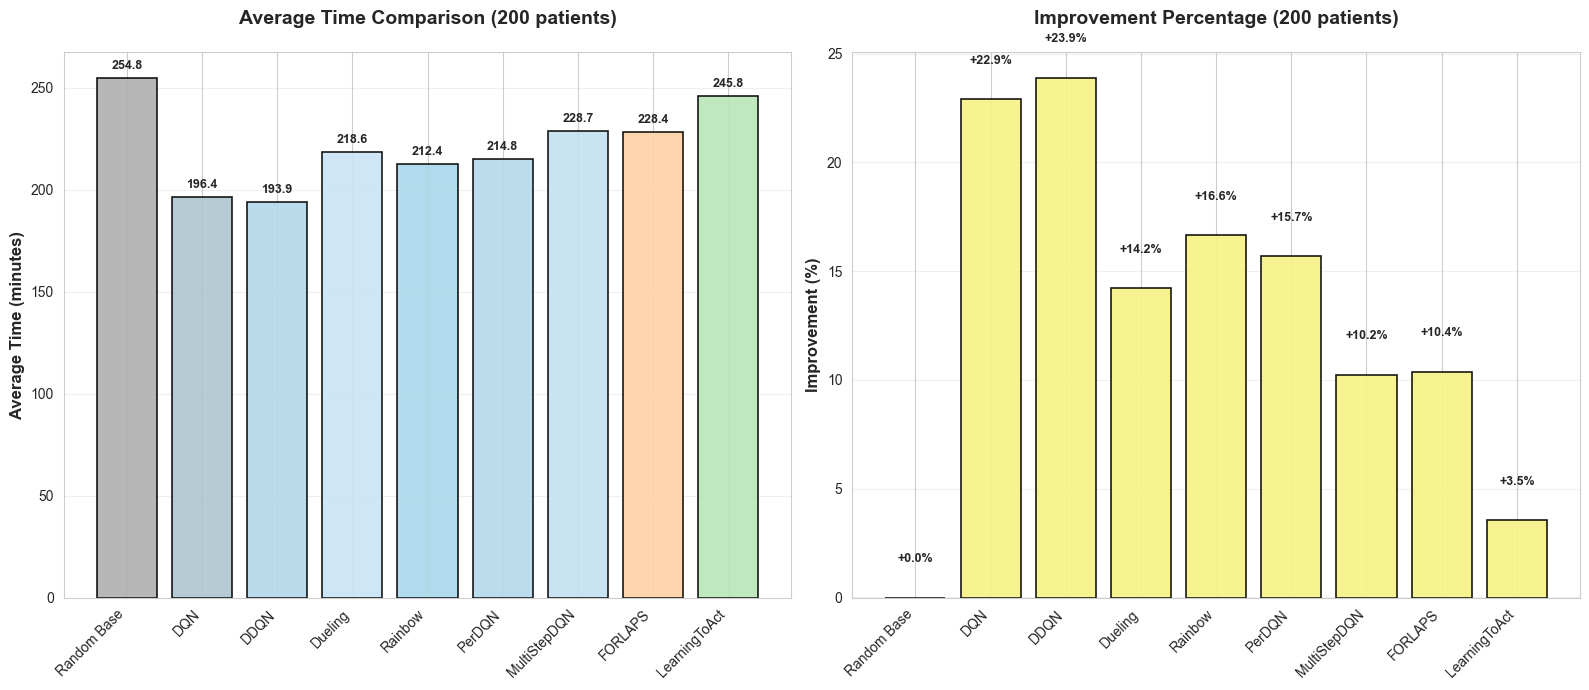

In [16]:
# Chạy cho 200 bệnh nhân
table1_200, table2_200 = generate_comparison_report(num_patients=200)


KẾT QUẢ SO SÁNH CHO 250 BỆNH NHÂN


📊 BẢNG 1: KẾT QUẢ THEO GENERATION (DQN-BASED MODELS)
--------------------------------------------------------------------------------
       Model  Gen 1  Gen 2  Gen 3
 Random Base 302.44    NaN    NaN
         DQN 262.30 245.29 288.70
        DDQN 268.11 279.98    NaN
     Dueling 279.13 262.59 275.38
     Rainbow 268.24 285.51    NaN
      PerDQN 260.17 260.34    NaN
MultiStepDQN 268.63 274.07    NaN


📊 BẢNG 2: SO SÁNH BEST RESULT CỦA TẤT CẢ MODELS
--------------------------------------------------------------------------------
        Model  Avg Time  Improve (%)
  Random Base    302.44     0.000000
          DQN    245.29    18.896310
         DDQN    268.11    11.351012
      Dueling    262.59    13.176167
      Rainbow    268.24    11.308028
       PerDQN    260.17    13.976326
 MultiStepDQN    268.63    11.179077
      FORLAPS    275.79     8.810000
LearningToAct    288.30     4.680000


✅ Đã lưu biểu đồ: comparison_report_250_patients.pdf



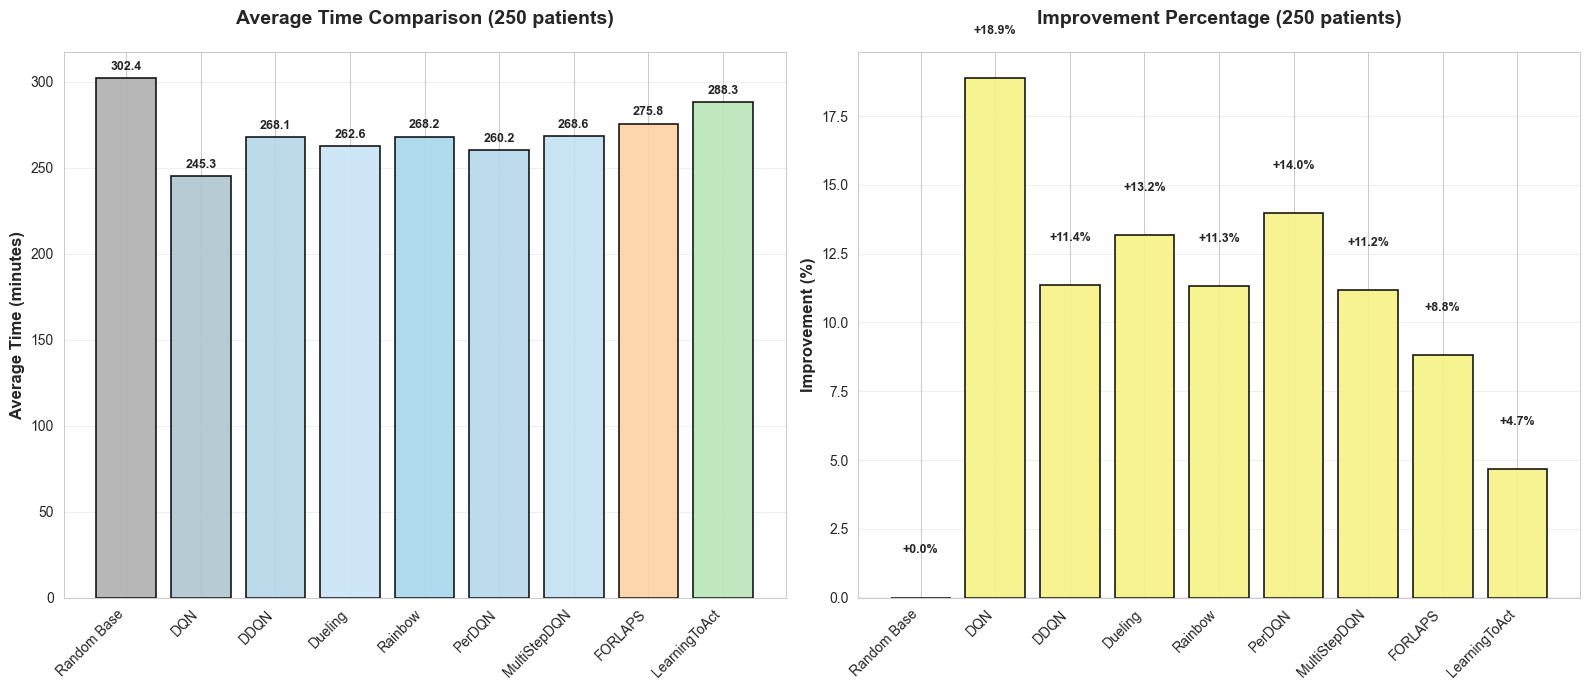

In [17]:
# Chạy cho 250 bệnh nhân
table1_250, table2_250 = generate_comparison_report(num_patients=250)


KẾT QUẢ SO SÁNH CHO 300 BỆNH NHÂN


📊 BẢNG 1: KẾT QUẢ THEO GENERATION (DQN-BASED MODELS)
--------------------------------------------------------------------------------
       Model  Gen 1  Gen 2  Gen 3  Gen 4  Gen 5
 Random Base 353.40    NaN    NaN    NaN    NaN
         DQN 316.52 322.28    NaN    NaN    NaN
        DDQN 310.79 327.68    NaN    NaN    NaN
     Dueling 311.47 317.81    NaN    NaN    NaN
     Rainbow 331.27 313.65 328.17    NaN    NaN
      PerDQN 323.05 340.79    NaN    NaN    NaN
MultiStepDQN 320.09 314.55 310.94 298.67 325.39


📊 BẢNG 2: SO SÁNH BEST RESULT CỦA TẤT CẢ MODELS
--------------------------------------------------------------------------------
        Model  Avg Time  Improve (%)
  Random Base    353.40     0.000000
          DQN    316.52    10.435767
         DDQN    310.79    12.057159
      Dueling    311.47    11.864743
      Rainbow    313.65    11.247878
       PerDQN    323.05     8.588002
 MultiStepDQN    298.67    15.486701
      FORLAPS    3

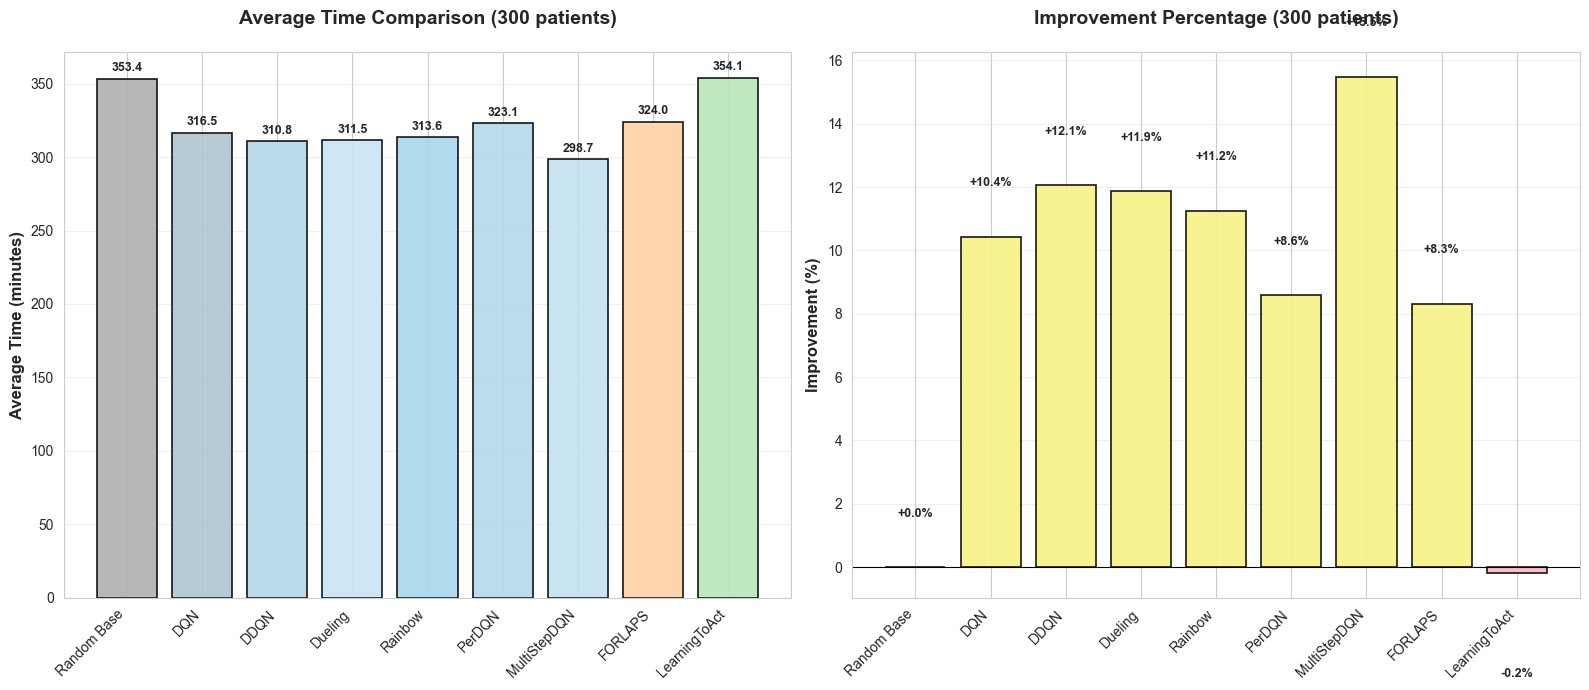

In [18]:
# Chạy cho 300 bệnh nhân
table1_300, table2_300 = generate_comparison_report(num_patients=300)